In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fftpack import fft

Filter parameters

In [19]:
srate = 1024
nyquist = srate / 2
frange = [20, 45] #Bandpass freq range

Creating Butterworth Filter

In [20]:
fkernB, fkernA = signal.butter(4, np.array(frange) / nyquist, btype = "bandpass")
#fkernB weights applied to the input signal
#fkernA weights applied to the filtered signal

Computing power spectrum

In [21]:
filtpow = np.abs(fft(fkernB)) **2
hz = np.linspace(0, srate/2, int(np.floor(len(fkernB)/2) + 1))

Plotting

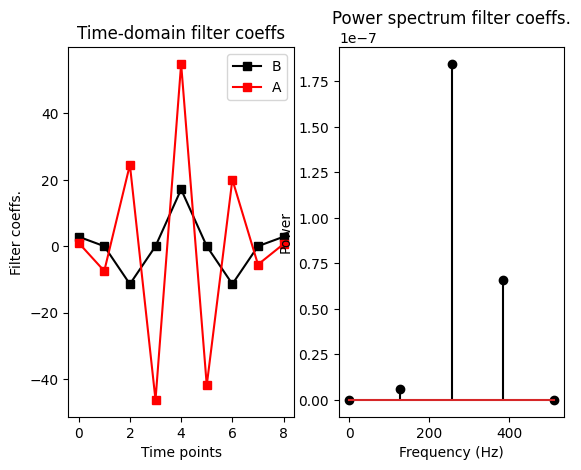

In [22]:
plt.subplot(121)
plt.plot(fkernB * 1e5, 'ks-', label='B')  #scaling B coefficients for visibility
plt.plot(fkernA, 'rs-', label='A')
plt.xlabel('Time points')
plt.ylabel('Filter coeffs.')
plt.title('Time-domain filter coeffs')
plt.legend()

plt.subplot(122)
plt.stem(hz, filtpow[0:len(hz)], 'ks-')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power spectrum filter coeffs.')
plt.show()

Generating impulse response

In [23]:
impres = np.zeros(1001)
impres[501] = 1

Applying the filter to the response

In [24]:
fimp = signal.lfilter(fkernB, fkernA, impres, axis=-1)

Powe spec

In [25]:
fimpX = np.abs(fft(fimp))**2
hz = np.linspace(0, nyquist, int(np.floor(len(impres)/2)+1))

Plotting

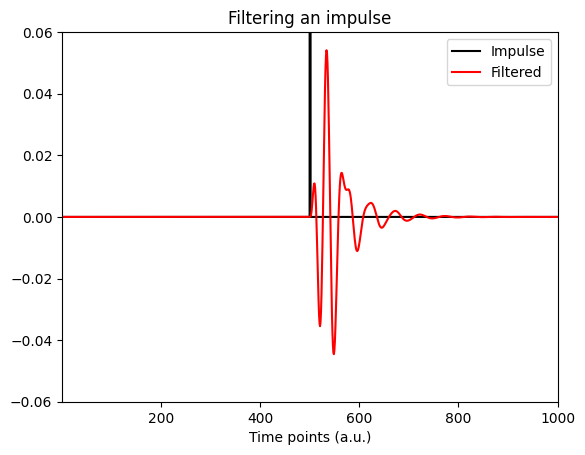

In [26]:
plt.plot(impres, 'k', label='Impulse')
plt.plot(fimp, 'r', label='Filtered')
plt.xlim([1, len(impres)])
plt.ylim([-.06, .06])
plt.legend()
plt.xlabel('Time points (a.u.)')
plt.title('Filtering an impulse')
plt.show()


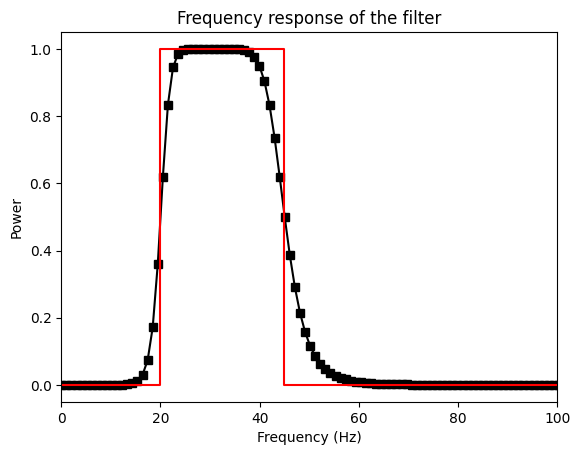

In [27]:
plt.plot(hz, fimpX[0:len(hz)], 'ks-')
plt.plot([0, frange[0], frange[0], frange[1], frange[1], nyquist], [0, 0, 1, 1, 0, 0], 'r')
plt.xlim([0, 100])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Frequency response of the filter')
plt.show()
